<a href="https://colab.research.google.com/github/pt2y1003/ColumbiaDS/blob/main/VaRNet_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

step= 100 loss=0.017217 alpha_corr=0.6283 var_med_abs_rel=0.1111
step= 200 loss=0.019574 alpha_corr=0.9775 var_med_abs_rel=0.1113
step= 300 loss=0.012874 alpha_corr=0.9674 var_med_abs_rel=0.1259
step= 400 loss=0.031748 alpha_corr=0.9890 var_med_abs_rel=0.2250
step= 500 loss=0.020153 alpha_corr=0.9887 var_med_abs_rel=0.1760
step= 600 loss=0.007771 alpha_corr=0.9767 var_med_abs_rel=0.0820
step= 700 loss=0.008108 alpha_corr=0.9689 var_med_abs_rel=0.1194
step= 800 loss=0.021487 alpha_corr=0.9683 var_med_abs_rel=0.2343
step= 900 loss=0.008975 alpha_corr=0.9789 var_med_abs_rel=0.0799
step=1000 loss=0.015026 alpha_corr=0.9783 var_med_abs_rel=0.1343
Test N = 335
VaR true = 268.60843663211756 VaR pred = 275.69122314453125 rel.err = 0.02636844397352453
alpha corr = 0.9779017043149134
Top-20 Jaccard = 0.7391304347826086


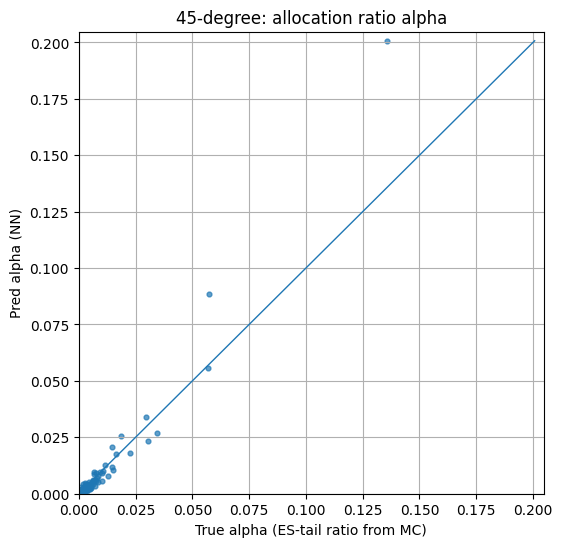

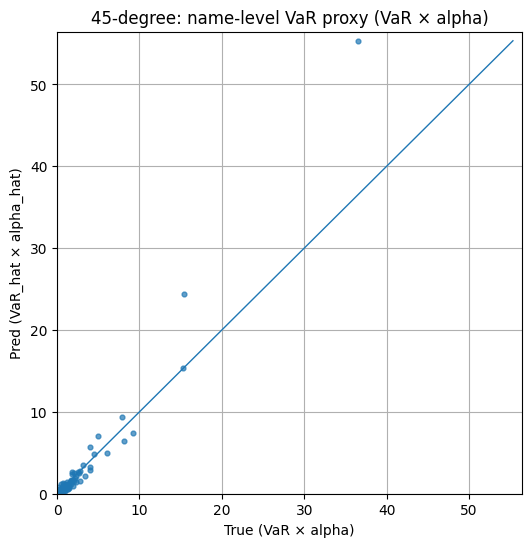

In [2]:
# ============================================================
# Multi-task Deep Sets: predict (VaR_q scalar, alpha vector)
# Teacher from ONE MC run per portfolio:
#   - VaR at q (default q=0.99)
#   - alpha = conditional expected loss ratio in ES tail (L >= VaR_q)
# Model: 1-factor Gaussian copula
# Inputs per obligor: (logEAD, logitPD, rho)
# Outputs:
#   - alpha_i (softmax, sum=1 on valid names)
#   - VaR_hat (positive scalar)
# Also provides 45-degree plots:
#   - alpha vs alpha
#   - (VaR*alpha) vs (VaR_hat*alpha_hat) (name-level VaR proxy)
# ============================================================

import math
import random
from dataclasses import dataclass, field
from typing import Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


# -----------------------------
# Utilities
# -----------------------------
def logit(p: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

def inv_norm_cdf(p: np.ndarray) -> np.ndarray:
    # Phi^{-1}(p) = sqrt(2)*erfinv(2p-1) using torch (no scipy)
    t = torch.tensor(p, dtype=torch.float64)
    z = math.sqrt(2.0) * torch.erfinv(2.0 * t - 1.0)
    return z.cpu().numpy()

def set_seed(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# -----------------------------
# Teacher generator (MC): VaR + ES-tail alpha
# -----------------------------
@dataclass
class TeacherConfig:
    q: float = 0.99            # VaR level (and ES tail threshold)
    lgd: float = 0.6
    mc_paths: int = 8000       # Colab-friendly
    min_tail_scenarios: int = 200

def simulate_var_and_alpha_es_tail(
    ead: np.ndarray,
    pd: np.ndarray,
    rho: np.ndarray,
    cfg: TeacherConfig
) -> Tuple[float, np.ndarray]:
    """
    1-factor Gaussian copula:
      Y_i = sqrt(rho_i)*Z + sqrt(1-rho_i)*eps_i
      default if Y_i < Phi^{-1}(PD_i)
      Loss_i = EAD_i * LGD * 1{default}
    Returns:
      VaR_q (scalar): quantile of portfolio loss at level q
      alpha (vector): E[Loss_i | L >= VaR_q] normalized to sum=1
    """
    n = ead.shape[0]
    M = cfg.mc_paths

    thr = inv_norm_cdf(pd)  # (n,)

    Z = np.random.randn(M, 1)         # (M,1)
    E = np.random.randn(M, n)         # (M,n)

    sqrt_rho = np.sqrt(rho).reshape(1, n)
    sqrt_1mr = np.sqrt(1.0 - rho).reshape(1, n)

    Y = sqrt_rho * Z + sqrt_1mr * E   # (M,n)
    D = (Y < thr.reshape(1, n))       # (M,n) bool

    loss_i = (ead.reshape(1, n) * cfg.lgd) * D.astype(np.float64)  # (M,n)
    L = loss_i.sum(axis=1)                                         # (M,)

    # VaR_q
    q = cfg.q
    idx_var = int(np.floor(q * (M - 1)))
    L_sorted = np.sort(L)
    var_q = float(L_sorted[idx_var])

    # ES tail mask
    tail = (L >= var_q)
    if tail.sum() < cfg.min_tail_scenarios:
        K = min(M, cfg.min_tail_scenarios)
        top_idx = np.argpartition(L, -K)[-K:]
        tail_mask = np.zeros(M, dtype=bool)
        tail_mask[top_idx] = True
        tail = tail_mask

    loss_i_tail = loss_i[tail]  # (T,n)
    if loss_i_tail.size == 0:
        return var_q, (np.ones(n, dtype=np.float32) / n)

    alpha = loss_i_tail.mean(axis=0)  # E[Loss_i | tail]
    s = alpha.sum()
    if s <= 0:
        return var_q, (np.ones(n, dtype=np.float32) / n)

    alpha = (alpha / s).astype(np.float32)
    return var_q, alpha


# -----------------------------
# Portfolio sampler
# -----------------------------
@dataclass
class PortfolioSamplerConfig:
    n_min: int = 50
    n_max: int = 400
    log_ead_mu: float = 2.0
    log_ead_sigma: float = 1.0
    pd_logit_mu: float = -4.0
    pd_logit_sigma: float = 1.0
    rho_a: float = 2.0
    rho_b: float = 10.0
    rho_min: float = 0.01
    rho_max: float = 0.40

def sample_portfolio(cfg: PortfolioSamplerConfig) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    n = np.random.randint(cfg.n_min, cfg.n_max + 1)

    log_ead = np.random.normal(cfg.log_ead_mu, cfg.log_ead_sigma, size=n)
    ead = np.exp(log_ead).astype(np.float64)

    pd_logit = np.random.normal(cfg.pd_logit_mu, cfg.pd_logit_sigma, size=n)
    pd = (1.0 / (1.0 + np.exp(-pd_logit))).astype(np.float64)
    pd = np.clip(pd, 1e-5, 0.3)

    rho_raw = np.random.beta(cfg.rho_a, cfg.rho_b, size=n)
    rho = (cfg.rho_min + (cfg.rho_max - cfg.rho_min) * rho_raw).astype(np.float64)

    return ead, pd, rho


# -----------------------------
# Deep Sets multi-task model
# -----------------------------
class MLP(nn.Module):
    def __init__(self, in_dim: int, hidden: int, out_dim: int, depth: int = 2, dropout: float = 0.0):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, hidden), nn.ReLU()]
            if dropout > 0:
                layers += [nn.Dropout(dropout)]
            d = hidden
        layers += [nn.Linear(d, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class DeepSetsVarAlpha(nn.Module):
    """
    Returns:
      alpha: (B,N) softmax on valid
      var_hat: (B,) positive scalar
    """
    def __init__(self, x_dim: int = 3, h_dim: int = 64, g_dim: int = 64):
        super().__init__()
        self.phi = MLP(x_dim, hidden=h_dim, out_dim=h_dim, depth=2)

        # Alpha head: per-name score using [h_i, g_mean, g_max, g_var]
        self.psi_alpha = MLP(h_dim + 3*h_dim, hidden=g_dim, out_dim=1, depth=2)

        # VaR head: use globals + a direct scale feature (log total EAD) for stability
        # globals: g_mean, g_max, g_var, g_sum  => 4*h_dim
        self.psi_var = MLP(4*h_dim + 1, hidden=g_dim, out_dim=1, depth=2)

    def forward(self, x: torch.Tensor, mask: torch.Tensor):
        """
        x: (B,N,3) padded
        mask: (B,N) bool
        """
        B, N, _ = x.shape
        h = self.phi(x)  # (B,N,h_dim)

        m = mask.unsqueeze(-1).float()          # (B,N,1)
        h_m = h * m
        denom = m.sum(dim=1).clamp_min(1.0)     # (B,1)

        g_mean = h_m.sum(dim=1) / denom         # (B,h_dim)
        h_for_max = h.clone()
        h_for_max[mask == 0] = -1e9
        g_max = h_for_max.max(dim=1).values     # (B,h_dim)

        g_sqmean = (h_m.pow(2).sum(dim=1) / denom)
        g_var = (g_sqmean - g_mean.pow(2)).clamp_min(0.0)  # (B,h_dim)

        g_sum = h_m.sum(dim=1)                  # (B,h_dim)

        # ----- alpha head -----
        g_alpha = torch.cat([g_mean, g_max, g_var], dim=-1)            # (B,3*h_dim)
        g_alpha_b = g_alpha.unsqueeze(1).expand(B, N, g_alpha.shape[-1])
        z = torch.cat([h, g_alpha_b], dim=-1)                          # (B,N,h_dim+3*h_dim)
        s = self.psi_alpha(z).squeeze(-1)                              # (B,N)
        s = s.masked_fill(mask == 0, -1e9)
        alpha = F.softmax(s, dim=1)

        # ----- VaR head -----
        # Direct scale: log total EAD from x[:,:,0] (logEAD)
        log_ead = x[:, :, 0]  # (B,N)
        log_total_ead = torch.logsumexp(log_ead.masked_fill(~mask, -1e9), dim=1)  # (B,)

        g_varfeat = torch.cat([g_mean, g_max, g_var, g_sum, log_total_ead.unsqueeze(-1)], dim=-1)  # (B,4*h_dim+1)
        var_raw = self.psi_var(g_varfeat).squeeze(-1)  # (B,)

        # ensure positive; predicting in "loss units"
        var_hat = F.softplus(var_raw) + 1e-8
        return alpha, var_hat


# -----------------------------
# Batch maker
# -----------------------------
def make_batch(portfolios, device="cpu"):
    B = len(portfolios)
    Nmax = max(p["x"].shape[0] for p in portfolios)

    x = torch.zeros(B, Nmax, 3, dtype=torch.float32)
    y_alpha = torch.zeros(B, Nmax, dtype=torch.float32)
    mask = torch.zeros(B, Nmax, dtype=torch.bool)
    y_var = torch.zeros(B, dtype=torch.float32)

    for b, p in enumerate(portfolios):
        n = p["x"].shape[0]
        x[b, :n] = torch.from_numpy(p["x"])
        y_alpha[b, :n] = torch.from_numpy(p["alpha"])
        mask[b, :n] = True
        y_var[b] = p["var"]

    return x.to(device), y_alpha.to(device), y_var.to(device), mask.to(device)


# -----------------------------
# Training
# -----------------------------
@dataclass
class TrainConfig:
    device: str = "cpu"
    steps: int = 5000
    batch_size: int = 8
    lr: float = 3e-4

    sampler_cfg: PortfolioSamplerConfig = field(default_factory=PortfolioSamplerConfig)
    teacher_cfg: TeacherConfig = field(default_factory=lambda: TeacherConfig(q=0.99, mc_paths=8000, lgd=0.6))

    # loss weights
    topk: int = 20
    topk_weight: float = 3.0
    var_weight: float = 1.0

def generate_one_portfolio(sampler_cfg: PortfolioSamplerConfig, teacher_cfg: TeacherConfig):
    ead, pd, rho = sample_portfolio(sampler_cfg)
    var_q, alpha = simulate_var_and_alpha_es_tail(ead, pd, rho, teacher_cfg)

    x = np.stack([
        np.log(ead).astype(np.float32),
        logit(pd).astype(np.float32),
        rho.astype(np.float32)
    ], axis=1)

    return {"x": x, "alpha": alpha, "var": float(var_q)}

def loss_alpha(pred_alpha, true_alpha, mask, topk=20, topk_weight=3.0):
    diff = pred_alpha - true_alpha
    base = F.smooth_l1_loss(diff[mask], torch.zeros_like(diff[mask]))

    # top-k emphasis per portfolio
    B, _ = true_alpha.shape
    extra_terms = []
    for b in range(B):
        mb = mask[b]
        tb = true_alpha[b][mb]
        pb = pred_alpha[b][mb]
        if tb.numel() <= 1:
            continue
        k = min(topk, tb.numel())
        idx = torch.topk(tb, k=k, largest=True).indices
        extra_terms.append(F.smooth_l1_loss(pb[idx], tb[idx]))
    extra = torch.stack(extra_terms).mean() if extra_terms else torch.tensor(0.0, device=true_alpha.device)

    return base + topk_weight * extra

def train_model(cfg: TrainConfig):
    device = cfg.device
    model = DeepSetsVarAlpha(x_dim=3, h_dim=64, g_dim=64).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=1e-4)

    model.train()
    for step in range(1, cfg.steps + 1):
        portfolios = [generate_one_portfolio(cfg.sampler_cfg, cfg.teacher_cfg) for _ in range(cfg.batch_size)]
        x, y_alpha, y_var, mask = make_batch(portfolios, device=device)

        pred_alpha, pred_var = model(x, mask)

        # alpha loss
        la = loss_alpha(pred_alpha, y_alpha, mask, topk=cfg.topk, topk_weight=cfg.topk_weight)

        # var loss: use log to stabilize scale
        lv = F.smooth_l1_loss(torch.log(pred_var), torch.log(y_var.clamp_min(1e-8)))

        loss = la + cfg.var_weight * lv

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if step % 100 == 0:
            with torch.no_grad():
                # alpha corr on valid
                pv = pred_alpha[mask].detach().cpu().numpy()
                tv = y_alpha[mask].detach().cpu().numpy()
                corr_a = np.corrcoef(pv, tv)[0, 1] if pv.size > 5 else np.nan

                # var relative error (median)
                rel = (pred_var.detach().cpu().numpy() - y_var.detach().cpu().numpy()) / (y_var.detach().cpu().numpy() + 1e-8)
                med_rel = float(np.median(np.abs(rel)))
            print(f"step={step:4d} loss={loss.item():.6f} alpha_corr={corr_a:.4f} var_med_abs_rel={med_rel:.4f}")

    return model


# -----------------------------
# Inference + test utilities
# -----------------------------
@torch.no_grad()
def predict_var_alpha(model, ead, pd, rho, device="cpu"):
    x = np.stack([np.log(ead).astype(np.float32),
                  logit(pd).astype(np.float32),
                  rho.astype(np.float32)], axis=1)
    x_t = torch.from_numpy(x).unsqueeze(0).to(device)
    mask = torch.ones(1, x.shape[0], dtype=torch.bool).to(device)
    model.eval()
    alpha_hat, var_hat = model(x_t, mask)
    return float(var_hat.squeeze(0).cpu().numpy()), alpha_hat.squeeze(0).cpu().numpy()

def jaccard_topk(true_alpha, pred_alpha, K=20):
    K = min(K, len(true_alpha))
    top_true = set(np.argsort(-true_alpha)[:K].tolist())
    top_pred = set(np.argsort(-pred_alpha)[:K].tolist())
    return len(top_true & top_pred) / max(1, len(top_true | top_pred))

def plot_45deg(x, y, title, xlabel, ylabel):
    mx = max(float(np.max(x)), float(np.max(y)))
    plt.figure(figsize=(6, 6))
    plt.scatter(x, y, s=12, alpha=0.7)
    plt.plot([0, mx], [0, mx], linewidth=1)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xlim(0, mx * 1.02)
    plt.ylim(0, mx * 1.02)
    plt.grid(True)
    plt.show()


# -----------------------------
# Run: train (step=1000) and test on one in-range portfolio
# -----------------------------
set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = TrainConfig(
    device=device,
    steps=1000,          # <- requested
    batch_size=8,
    lr=3e-4,
    teacher_cfg=TeacherConfig(q=0.99, mc_paths=8000, lgd=0.6, min_tail_scenarios=200),
    var_weight=1.0,
)

model = train_model(cfg)

# ---- fixed-seed test portfolio & fixed-seed teacher MC for reproducibility ----
TEST_SEED = 12345
np.random.seed(TEST_SEED)
test_ead, test_pd, test_rho = sample_portfolio(cfg.sampler_cfg)

# High-precision teacher for test (reduce noise)
np.random.seed(TEST_SEED + 1)  # separate seed so portfolio draw and MC draw are both reproducible
teacher_cfg_test = TeacherConfig(q=0.99, lgd=cfg.teacher_cfg.lgd, mc_paths=50000, min_tail_scenarios=500)
true_var, true_alpha = simulate_var_and_alpha_es_tail(test_ead, test_pd, test_rho, teacher_cfg_test)

pred_var, pred_alpha = predict_var_alpha(model, test_ead, test_pd, test_rho, device=device)

print("Test N =", len(test_ead))
print("VaR true =", true_var, "VaR pred =", pred_var, "rel.err =", (pred_var-true_var)/(true_var+1e-8))

corr_alpha = np.corrcoef(true_alpha, pred_alpha)[0, 1] if len(true_alpha) > 5 else np.nan
print("alpha corr =", float(corr_alpha))
print("Top-20 Jaccard =", jaccard_topk(true_alpha, pred_alpha, K=20))

# ---- 45-degree plots ----
plot_45deg(true_alpha, pred_alpha,
           title="45-degree: allocation ratio alpha",
           xlabel="True alpha (ES-tail ratio from MC)",
           ylabel="Pred alpha (NN)")

# name-level VaR proxy = VaR * alpha
true_name_var = true_var * true_alpha
pred_name_var = pred_var * pred_alpha

plot_45deg(true_name_var, pred_name_var,
           title="45-degree: name-level VaR proxy (VaR × alpha)",
           xlabel="True (VaR × alpha)",
           ylabel="Pred (VaR_hat × alpha_hat)")


In [3]:
device

'cuda'

step= 100 loss=0.017217 alpha_corr=0.6283 var_med_abs_rel=0.1111
step= 200 loss=0.019574 alpha_corr=0.9775 var_med_abs_rel=0.1113
step= 300 loss=0.012874 alpha_corr=0.9674 var_med_abs_rel=0.1259
step= 400 loss=0.031748 alpha_corr=0.9890 var_med_abs_rel=0.2250
step= 500 loss=0.020153 alpha_corr=0.9887 var_med_abs_rel=0.1760
step= 600 loss=0.007771 alpha_corr=0.9767 var_med_abs_rel=0.0820
step= 700 loss=0.008108 alpha_corr=0.9689 var_med_abs_rel=0.1194
step= 800 loss=0.021487 alpha_corr=0.9683 var_med_abs_rel=0.2343
step= 900 loss=0.008975 alpha_corr=0.9789 var_med_abs_rel=0.0799
step=1000 loss=0.015026 alpha_corr=0.9783 var_med_abs_rel=0.1343
step=1100 loss=0.027839 alpha_corr=0.9828 var_med_abs_rel=0.1142
step=1200 loss=0.044838 alpha_corr=0.9910 var_med_abs_rel=0.0274
step=1300 loss=0.044214 alpha_corr=0.9841 var_med_abs_rel=0.1076
step=1400 loss=0.007295 alpha_corr=0.9742 var_med_abs_rel=0.0802
step=1500 loss=0.005346 alpha_corr=0.9825 var_med_abs_rel=0.0431
step=1600 loss=0.012467 a

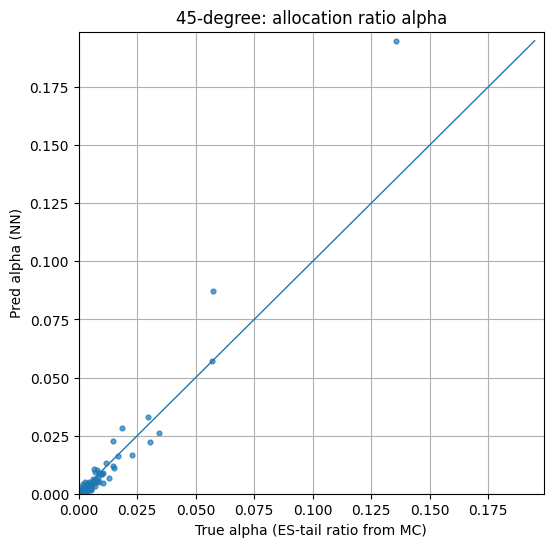

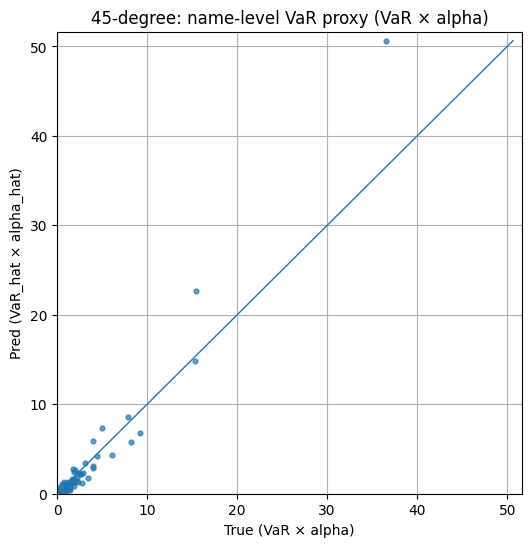

In [5]:
# ============================================================
# Multi-task Deep Sets: predict (VaR_q scalar, alpha vector)
# Teacher from ONE MC run per portfolio:
#   - VaR at q (default q=0.99)
#   - alpha = conditional expected loss ratio in ES tail (L >= VaR_q)
# Model: 1-factor Gaussian copula
# Inputs per obligor: (logEAD, logitPD, rho)
# Outputs:
#   - alpha_i (softmax, sum=1 on valid names)
#   - VaR_hat (positive scalar)
# Also provides 45-degree plots:
#   - alpha vs alpha
#   - (VaR*alpha) vs (VaR_hat*alpha_hat) (name-level VaR proxy)
# ============================================================

import math
import random
from dataclasses import dataclass, field
from typing import Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt


# -----------------------------
# Utilities
# -----------------------------
def logit(p: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

def inv_norm_cdf(p: np.ndarray) -> np.ndarray:
    # Phi^{-1}(p) = sqrt(2)*erfinv(2p-1) using torch (no scipy)
    t = torch.tensor(p, dtype=torch.float64)
    z = math.sqrt(2.0) * torch.erfinv(2.0 * t - 1.0)
    return z.cpu().numpy()

def set_seed(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


# -----------------------------
# Teacher generator (MC): VaR + ES-tail alpha
# -----------------------------
@dataclass
class TeacherConfig:
    q: float = 0.99            # VaR level (and ES tail threshold)
    lgd: float = 0.6
    mc_paths: int = 8000       # Colab-friendly
    min_tail_scenarios: int = 200

def simulate_var_and_alpha_es_tail(
    ead: np.ndarray,
    pd: np.ndarray,
    rho: np.ndarray,
    cfg: TeacherConfig
) -> Tuple[float, np.ndarray]:
    """
    1-factor Gaussian copula:
      Y_i = sqrt(rho_i)*Z + sqrt(1-rho_i)*eps_i
      default if Y_i < Phi^{-1}(PD_i)
      Loss_i = EAD_i * LGD * 1{default}
    Returns:
      VaR_q (scalar): quantile of portfolio loss at level q
      alpha (vector): E[Loss_i | L >= VaR_q] normalized to sum=1
    """
    n = ead.shape[0]
    M = cfg.mc_paths

    thr = inv_norm_cdf(pd)  # (n,)

    Z = np.random.randn(M, 1)         # (M,1)
    E = np.random.randn(M, n)         # (M,n)

    sqrt_rho = np.sqrt(rho).reshape(1, n)
    sqrt_1mr = np.sqrt(1.0 - rho).reshape(1, n)

    Y = sqrt_rho * Z + sqrt_1mr * E   # (M,n)
    D = (Y < thr.reshape(1, n))       # (M,n) bool

    loss_i = (ead.reshape(1, n) * cfg.lgd) * D.astype(np.float64)  # (M,n)
    L = loss_i.sum(axis=1)                                         # (M,)

    # VaR_q
    q = cfg.q
    idx_var = int(np.floor(q * (M - 1)))
    L_sorted = np.sort(L)
    var_q = float(L_sorted[idx_var])

    # ES tail mask
    tail = (L >= var_q)
    if tail.sum() < cfg.min_tail_scenarios:
        K = min(M, cfg.min_tail_scenarios)
        top_idx = np.argpartition(L, -K)[-K:]
        tail_mask = np.zeros(M, dtype=bool)
        tail_mask[top_idx] = True
        tail = tail_mask

    loss_i_tail = loss_i[tail]  # (T,n)
    if loss_i_tail.size == 0:
        return var_q, (np.ones(n, dtype=np.float32) / n)

    alpha = loss_i_tail.mean(axis=0)  # E[Loss_i | tail]
    s = alpha.sum()
    if s <= 0:
        return var_q, (np.ones(n, dtype=np.float32) / n)

    alpha = (alpha / s).astype(np.float32)
    return var_q, alpha


# -----------------------------
# Portfolio sampler
# -----------------------------
@dataclass
class PortfolioSamplerConfig:
    n_min: int = 50
    n_max: int = 400
    log_ead_mu: float = 2.0
    log_ead_sigma: float = 1.0
    pd_logit_mu: float = -4.0
    pd_logit_sigma: float = 1.0
    rho_a: float = 2.0
    rho_b: float = 10.0
    rho_min: float = 0.01
    rho_max: float = 0.40

def sample_portfolio(cfg: PortfolioSamplerConfig) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    n = np.random.randint(cfg.n_min, cfg.n_max + 1)

    log_ead = np.random.normal(cfg.log_ead_mu, cfg.log_ead_sigma, size=n)
    ead = np.exp(log_ead).astype(np.float64)

    pd_logit = np.random.normal(cfg.pd_logit_mu, cfg.pd_logit_sigma, size=n)
    pd = (1.0 / (1.0 + np.exp(-pd_logit))).astype(np.float64)
    pd = np.clip(pd, 1e-5, 0.3)

    rho_raw = np.random.beta(cfg.rho_a, cfg.rho_b, size=n)
    rho = (cfg.rho_min + (cfg.rho_max - cfg.rho_min) * rho_raw).astype(np.float64)

    return ead, pd, rho


# -----------------------------
# Deep Sets multi-task model
# -----------------------------
class MLP(nn.Module):
    def __init__(self, in_dim: int, hidden: int, out_dim: int, depth: int = 2, dropout: float = 0.0):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, hidden), nn.ReLU()]
            if dropout > 0:
                layers += [nn.Dropout(dropout)]
            d = hidden
        layers += [nn.Linear(d, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class DeepSetsVarAlpha(nn.Module):
    """
    Returns:
      alpha: (B,N) softmax on valid
      var_hat: (B,) positive scalar
    """
    def __init__(self, x_dim: int = 3, h_dim: int = 64, g_dim: int = 64):
        super().__init__()
        self.phi = MLP(x_dim, hidden=h_dim, out_dim=h_dim, depth=2)

        # Alpha head: per-name score using [h_i, g_mean, g_max, g_var]
        self.psi_alpha = MLP(h_dim + 3*h_dim, hidden=g_dim, out_dim=1, depth=2)

        # VaR head: use globals + a direct scale feature (log total EAD) for stability
        # globals: g_mean, g_max, g_var, g_sum  => 4*h_dim
        self.psi_var = MLP(4*h_dim + 1, hidden=g_dim, out_dim=1, depth=2)

    def forward(self, x: torch.Tensor, mask: torch.Tensor):
        """
        x: (B,N,3) padded
        mask: (B,N) bool
        """
        B, N, _ = x.shape
        h = self.phi(x)  # (B,N,h_dim)

        m = mask.unsqueeze(-1).float()          # (B,N,1)
        h_m = h * m
        denom = m.sum(dim=1).clamp_min(1.0)     # (B,1)

        g_mean = h_m.sum(dim=1) / denom         # (B,h_dim)
        h_for_max = h.clone()
        h_for_max[mask == 0] = -1e9
        g_max = h_for_max.max(dim=1).values     # (B,h_dim)

        g_sqmean = (h_m.pow(2).sum(dim=1) / denom)
        g_var = (g_sqmean - g_mean.pow(2)).clamp_min(0.0)  # (B,h_dim)

        g_sum = h_m.sum(dim=1)                  # (B,h_dim)

        # ----- alpha head -----
        g_alpha = torch.cat([g_mean, g_max, g_var], dim=-1)            # (B,3*h_dim)
        g_alpha_b = g_alpha.unsqueeze(1).expand(B, N, g_alpha.shape[-1])
        z = torch.cat([h, g_alpha_b], dim=-1)                          # (B,N,h_dim+3*h_dim)
        s = self.psi_alpha(z).squeeze(-1)                              # (B,N)
        s = s.masked_fill(mask == 0, -1e9)
        alpha = F.softmax(s, dim=1)

        # ----- VaR head -----
        # Direct scale: log total EAD from x[:,:,0] (logEAD)
        log_ead = x[:, :, 0]  # (B,N)
        log_total_ead = torch.logsumexp(log_ead.masked_fill(~mask, -1e9), dim=1)  # (B,)

        g_varfeat = torch.cat([g_mean, g_max, g_var, g_sum, log_total_ead.unsqueeze(-1)], dim=-1)  # (B,4*h_dim+1)
        var_raw = self.psi_var(g_varfeat).squeeze(-1)  # (B,)

        # ensure positive; predicting in "loss units"
        var_hat = F.softplus(var_raw) + 1e-8
        return alpha, var_hat


# -----------------------------
# Batch maker
# -----------------------------
def make_batch(portfolios, device="cpu"):
    B = len(portfolios)
    Nmax = max(p["x"].shape[0] for p in portfolios)

    x = torch.zeros(B, Nmax, 3, dtype=torch.float32)
    y_alpha = torch.zeros(B, Nmax, dtype=torch.float32)
    mask = torch.zeros(B, Nmax, dtype=torch.bool)
    y_var = torch.zeros(B, dtype=torch.float32)

    for b, p in enumerate(portfolios):
        n = p["x"].shape[0]
        x[b, :n] = torch.from_numpy(p["x"])
        y_alpha[b, :n] = torch.from_numpy(p["alpha"])
        mask[b, :n] = True
        y_var[b] = p["var"]

    return x.to(device), y_alpha.to(device), y_var.to(device), mask.to(device)


# -----------------------------
# Training
# -----------------------------
@dataclass
class TrainConfig:
    device: str = "cpu"
    steps: int = 5000
    batch_size: int = 8
    lr: float = 3e-4

    sampler_cfg: PortfolioSamplerConfig = field(default_factory=PortfolioSamplerConfig)
    teacher_cfg: TeacherConfig = field(default_factory=lambda: TeacherConfig(q=0.99, mc_paths=8000, lgd=0.6))

    # loss weights
    topk: int = 20
    topk_weight: float = 3.0
    var_weight: float = 1.0

def generate_one_portfolio(sampler_cfg: PortfolioSamplerConfig, teacher_cfg: TeacherConfig):
    ead, pd, rho = sample_portfolio(sampler_cfg)
    var_q, alpha = simulate_var_and_alpha_es_tail(ead, pd, rho, teacher_cfg)

    x = np.stack([
        np.log(ead).astype(np.float32),
        logit(pd).astype(np.float32),
        rho.astype(np.float32)
    ], axis=1)

    return {"x": x, "alpha": alpha, "var": float(var_q)}

def loss_alpha(pred_alpha, true_alpha, mask, topk=20, topk_weight=3.0):
    diff = pred_alpha - true_alpha
    base = F.smooth_l1_loss(diff[mask], torch.zeros_like(diff[mask]))

    # top-k emphasis per portfolio
    B, _ = true_alpha.shape
    extra_terms = []
    for b in range(B):
        mb = mask[b]
        tb = true_alpha[b][mb]
        pb = pred_alpha[b][mb]
        if tb.numel() <= 1:
            continue
        k = min(topk, tb.numel())
        idx = torch.topk(tb, k=k, largest=True).indices
        extra_terms.append(F.smooth_l1_loss(pb[idx], tb[idx]))
    extra = torch.stack(extra_terms).mean() if extra_terms else torch.tensor(0.0, device=true_alpha.device)

    return base + topk_weight * extra

def train_model(cfg: TrainConfig):
    device = cfg.device
    model = DeepSetsVarAlpha(x_dim=3, h_dim=64, g_dim=64).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=1e-4)

    model.train()
    for step in range(1, cfg.steps + 1):
        portfolios = [generate_one_portfolio(cfg.sampler_cfg, cfg.teacher_cfg) for _ in range(cfg.batch_size)]
        x, y_alpha, y_var, mask = make_batch(portfolios, device=device)

        pred_alpha, pred_var = model(x, mask)

        # alpha loss
        la = loss_alpha(pred_alpha, y_alpha, mask, topk=cfg.topk, topk_weight=cfg.topk_weight)

        # var loss: use log to stabilize scale
        lv = F.smooth_l1_loss(torch.log(pred_var), torch.log(y_var.clamp_min(1e-8)))

        loss = la + cfg.var_weight * lv

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if step % 100 == 0:
            with torch.no_grad():
                # alpha corr on valid
                pv = pred_alpha[mask].detach().cpu().numpy()
                tv = y_alpha[mask].detach().cpu().numpy()
                corr_a = np.corrcoef(pv, tv)[0, 1] if pv.size > 5 else np.nan

                # var relative error (median)
                rel = (pred_var.detach().cpu().numpy() - y_var.detach().cpu().numpy()) / (y_var.detach().cpu().numpy() + 1e-8)
                med_rel = float(np.median(np.abs(rel)))
            print(f"step={step:4d} loss={loss.item():.6f} alpha_corr={corr_a:.4f} var_med_abs_rel={med_rel:.4f}")

    return model


# -----------------------------
# Inference + test utilities
# -----------------------------
@torch.no_grad()
def predict_var_alpha(model, ead, pd, rho, device="cpu"):
    x = np.stack([np.log(ead).astype(np.float32),
                  logit(pd).astype(np.float32),
                  rho.astype(np.float32)], axis=1)
    x_t = torch.from_numpy(x).unsqueeze(0).to(device)
    mask = torch.ones(1, x.shape[0], dtype=torch.bool).to(device)
    model.eval()
    alpha_hat, var_hat = model(x_t, mask)
    return float(var_hat.squeeze(0).cpu().numpy()), alpha_hat.squeeze(0).cpu().numpy()

def jaccard_topk(true_alpha, pred_alpha, K=20):
    K = min(K, len(true_alpha))
    top_true = set(np.argsort(-true_alpha)[:K].tolist())
    top_pred = set(np.argsort(-pred_alpha)[:K].tolist())
    return len(top_true & top_pred) / max(1, len(top_true | top_pred))

def plot_45deg(x, y, title, xlabel, ylabel):
    mx = max(float(np.max(x)), float(np.max(y)))
    plt.figure(figsize=(6, 6))
    plt.scatter(x, y, s=12, alpha=0.7)
    plt.plot([0, mx], [0, mx], linewidth=1)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xlim(0, mx * 1.02)
    plt.ylim(0, mx * 1.02)
    plt.grid(True)
    plt.show()


# -----------------------------
# Run: train (step=1000) and test on one in-range portfolio
# -----------------------------
set_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

cfg = TrainConfig(
    device=device,
    steps=5000,          # <- requested
    batch_size=8,
    lr=3e-4,
    teacher_cfg=TeacherConfig(q=0.99, mc_paths=8000, lgd=0.6, min_tail_scenarios=200),
    var_weight=1.0,
)

model = train_model(cfg)

# ---- fixed-seed test portfolio & fixed-seed teacher MC for reproducibility ----
TEST_SEED = 12345
np.random.seed(TEST_SEED)
test_ead, test_pd, test_rho = sample_portfolio(cfg.sampler_cfg)

# High-precision teacher for test (reduce noise)
np.random.seed(TEST_SEED + 1)  # separate seed so portfolio draw and MC draw are both reproducible
teacher_cfg_test = TeacherConfig(q=0.99, lgd=cfg.teacher_cfg.lgd, mc_paths=50000, min_tail_scenarios=500)
true_var, true_alpha = simulate_var_and_alpha_es_tail(test_ead, test_pd, test_rho, teacher_cfg_test)

pred_var, pred_alpha = predict_var_alpha(model, test_ead, test_pd, test_rho, device=device)

print("Test N =", len(test_ead))
print("VaR true =", true_var, "VaR pred =", pred_var, "rel.err =", (pred_var-true_var)/(true_var+1e-8))

corr_alpha = np.corrcoef(true_alpha, pred_alpha)[0, 1] if len(true_alpha) > 5 else np.nan
print("alpha corr =", float(corr_alpha))
print("Top-20 Jaccard =", jaccard_topk(true_alpha, pred_alpha, K=20))

# ---- 45-degree plots ----
plot_45deg(true_alpha, pred_alpha,
           title="45-degree: allocation ratio alpha",
           xlabel="True alpha (ES-tail ratio from MC)",
           ylabel="Pred alpha (NN)")

# name-level VaR proxy = VaR * alpha
true_name_var = true_var * true_alpha
pred_name_var = pred_var * pred_alpha

plot_45deg(true_name_var, pred_name_var,
           title="45-degree: name-level VaR proxy (VaR × alpha)",
           xlabel="True (VaR × alpha)",
           ylabel="Pred (VaR_hat × alpha_hat)")
